# Modelling data - Version 6

This version includes all variables in the dataset **except for economic indicators, fuel consumption and cost variables**: FUEL_CONS_ACPM, FUEL_CONS_CARBON, FUEL_CONS_COMBUSTOLEO, FUEL_CONS_CRUDO, FUEL_CONS_GAS, FUEL_CONS_GAS_NI, FUEL_CONS_GLP, FUEL_COST_CARBON, FUEL_COST_GAS, FUEL_COST_GAS_NI, FUEL_COST_COMBUSTOLEO, IPC_VAR_MOM_PCT, IPP_VAR_PN_MOM_PCT, IPP_VAR_OI_MOM_PCT.

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [1]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

## Dataset

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


In [3]:
# Dropping column "SOLAR"

df = df.drop(columns=["FUEL_CONS_ACPM", "FUEL_CONS_CARBON", "FUEL_CONS_COMBUSTOLEO", 
                      "FUEL_CONS_CRUDO", "FUEL_CONS_GAS", "FUEL_CONS_GAS_NI", "FUEL_CONS_GLP",
                      "FUEL_COST_CARBON", "FUEL_COST_GAS", "FUEL_COST_GAS_NI", "FUEL_COST_COMBUSTOLEO",
                      "IPC_VAR_MOM_PCT", "IPP_VAR_PN_MOM_PCT", "IPP_VAR_OI_MOM_PCT"])
df.head()

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0


In [4]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48192 entries, 0 to 48191
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   FECHA_HORA   48192 non-null  object 
 1   YEAR         48192 non-null  int64  
 2   MONTH        48192 non-null  int64  
 3   DAY          48192 non-null  int64  
 4   HORA         48192 non-null  int64  
 5   PRECIO       48192 non-null  float64
 6   TERMICA      48192 non-null  float64
 7   HIDRAULICA   48192 non-null  float64
 8   SOLAR        48192 non-null  float64
 9   COGENERADOR  48192 non-null  float64
 10  EOLICA       48192 non-null  float64
 11  NIVEL_ENSO   48192 non-null  float64
dtypes: float64(7), int64(4), object(1)
memory usage: 4.4+ MB
None


In [5]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA     0
YEAR           0
MONTH          0
DAY            0
HORA           0
PRECIO         0
TERMICA        0
HIDRAULICA     0
SOLAR          0
COGENERADOR    0
EOLICA         0
NIVEL_ENSO     0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [6]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [7]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 10)
Test set size: (9639, 10)


## Baseline Models

In [8]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

In [9]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression  0.206866  137.530357   49064.596946  196.469670
Ridge              0.206895  137.529693   49064.447148  196.468096
Lasso              0.211182  137.373887   48942.611158  196.047478
ElasticNet         0.243902  143.813107   54000.526870  198.711099
Decision Tree     -0.216417  168.943740   92760.753147  256.124429
Random Forest      0.009213  153.603437   75697.734854  231.460315
Gradient Boosting  0.121609  137.427888   68025.355476  216.064384
SVR               -0.671299  232.626961  131134.323579  304.217181
KNN               -0.203395  163.009283   73128.899508  236.687305


In [10]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [11]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [12]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: 0.26894262410664255
Best params: {'model__alpha': 1, 'model__l1_ratio': 0.7}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: 0.1145322884613859
Best params: {'model__max_depth': 5, 'model__min_samples_split': 10, 'model__n_estimators': 500}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: 0.3273542541702135
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}


{'ElasticNet': {'best_score': 0.26894262410664255,
  'best_params': {'model__alpha': 1, 'model__l1_ratio': 0.7}},
 'RandomForest': {'best_score': 0.1145322884613859,
  'best_params': {'model__max_depth': 5,
   'model__min_samples_split': 10,
   'model__n_estimators': 500}},
 'GradientBoosting': {'best_score': 0.3273542541702135,
  'best_params': {'model__learning_rate': 0.01,
   'model__max_depth': 5,
   'model__n_estimators': 200}}}

In [13]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [14]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [15]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,0.078512,146.269814,64944.614665,217.222424
LightGBM,0.336692,129.476060,57677.415537,197.374705
CatBoost,0.106683,149.432041,76738.564367,226.414301


## Time Series Forecasting

### Splits the training and test sets as a time series

In [16]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 10)
Test set size: (9639, 10)


In [17]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression  0.109539  163.169935   66021.040259  224.197288
Ridge              0.109524  163.169618   66021.210800  224.197637
Lasso              0.124218  161.185060   64897.220135  222.031443
ElasticNet        -0.179366  177.290475   76951.861823  241.702903
Decision Tree     -0.254374  167.017745   81014.581448  243.778601
Random Forest     -0.002579  160.564566   79578.584421  232.920597
Gradient Boosting  0.115063  142.166269   60139.927660  210.312190
SVR               -1.181794  252.509696  155977.743813  338.530789
KNN               -0.401894  181.756212   79193.603184  250.568416


### Prophet

In [18]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0


00:37:00 - cmdstanpy - INFO - Chain [1] start processing
00:38:11 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecasting Results:
MAE: 266.23, RMSE: 450.33, R2: 0.19


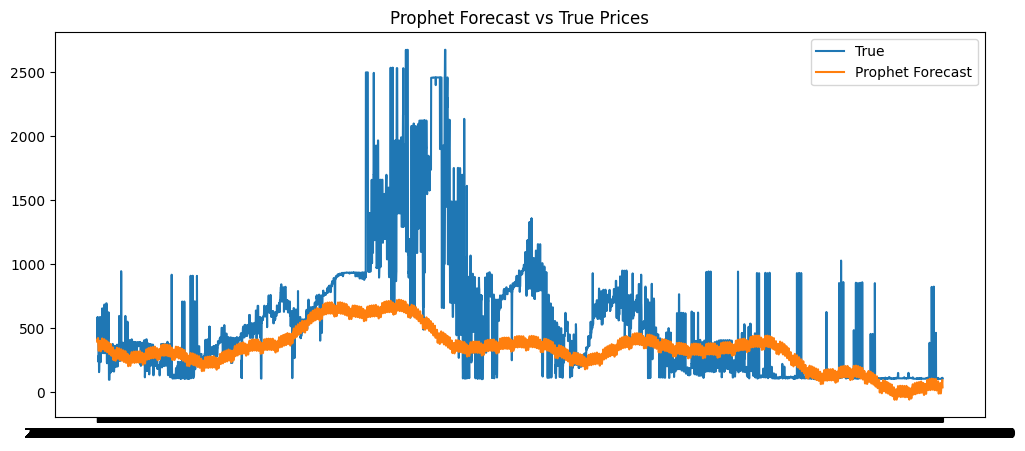

In [19]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = root_mean_squared_error(test_df["y"], pred_prophet)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

XGBoost with Prophet feature:
MAE: 222.99, RMSE: 407.47, R2: 0.34


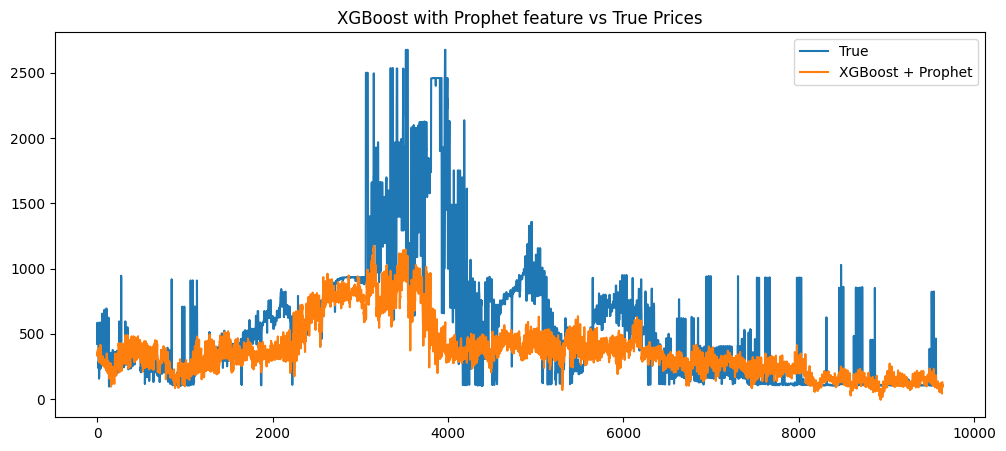

In [20]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [21]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [22]:
X_train.head()

,YEAR,MONTH,DAY,HORA,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
24,2020,1,2,0,1608662.67,4585681.98,0.0,19184.34,4908.48,1.0,...,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71,72.02
25,2020,1,2,1,1508655.14,4466153.60,0.0,19342.06,3836.61,1.0,...,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71
26,2020,1,2,2,1413968.65,4520386.10,0.0,20345.52,5343.35,1.0,...,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71
27,2020,1,2,3,1369278.08,4470436.67,0.0,21123.41,3942.81,1.0,...,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71
28,2020,1,2,4,1353049.36,4558570.93,0.0,25773.80,2363.15,1.0,...,136.71,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71


### XGBoost Forecasting with Lags

XGBoost Forecasting Results:
MAE: 87.69, RMSE: 250.03, R2: 0.75


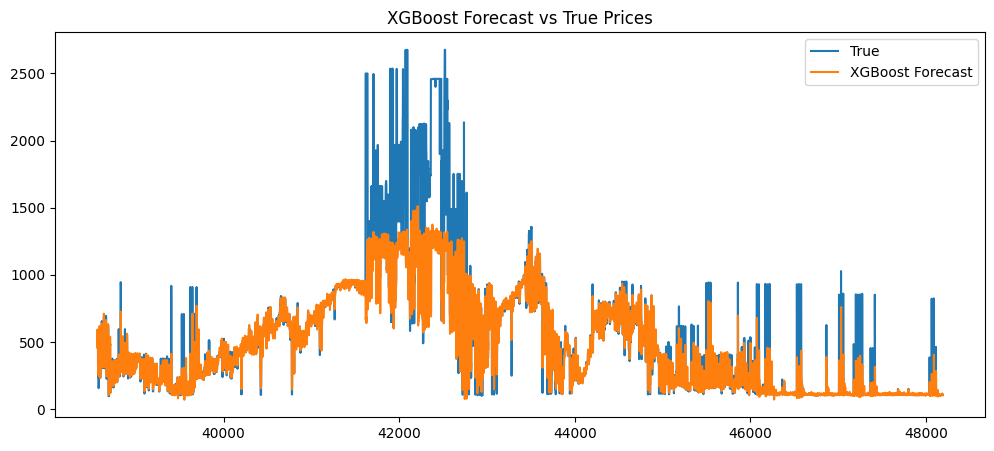

In [23]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = root_mean_squared_error(y_test, pred_xgb)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [24]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7477
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 34
[LightGBM] [Info] Start training from score 318.370624
                MAE        RMSE        R2
XGBoost   87.903057  249.126161  0.753144
LightGBM  80.199449  224.102830  0.800244
CatBoost  81.140203  223.600848  0.801138


### Boosting with lags (tunning)

In [26]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE

In [27]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


[I 2025-08-30 00:40:37,276] A new study created in memory with name: no-name-d2a59271-9b93-4ef9-b320-ff7d41292c91


Running Optuna for XGBoost...


[I 2025-08-30 00:40:47,457] Trial 0 finished with value: 235.97439622133317 and parameters: {'n_estimators': 1447, 'learning_rate': 0.014103627317323208, 'max_depth': 5, 'subsample': 0.6154593100981812, 'colsample_bytree': 0.9492876900445704, 'gamma': 2.229509865094548, 'reg_alpha': 0.3800211912884266, 'reg_lambda': 1.792780329608235}. Best is trial 0 with value: 235.97439622133317.
[I 2025-08-30 00:40:51,883] Trial 1 finished with value: 230.3156272559526 and parameters: {'n_estimators': 816, 'learning_rate': 0.12785320386990723, 'max_depth': 4, 'subsample': 0.8408075282390498, 'colsample_bytree': 0.8262254729919694, 'gamma': 0.7569439734661676, 'reg_alpha': 1.8387608067945798, 'reg_lambda': 2.546297615375278}. Best is trial 1 with value: 230.3156272559526.
[I 2025-08-30 00:41:16,508] Trial 2 finished with value: 252.03739306606545 and parameters: {'n_estimators': 585, 'learning_rate': 0.06389098527207826, 'max_depth': 12, 'subsample': 0.7389411795232688, 'colsample_bytree': 0.6412274

Best params for XGBoost: {'n_estimators': 845, 'learning_rate': 0.012388656452353795, 'max_depth': 3, 'subsample': 0.9302478871873637, 'colsample_bytree': 0.9271801218461874, 'gamma': 2.8032447818748856, 'reg_alpha': 3.2519014186286967, 'reg_lambda': 3.826028818750822}
Best RMSE: 215.6523

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7477
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 34
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

[I 2025-08-30 00:50:48,614] Trial 0 finished with value: 226.61986375333814 and parameters: {'n_estimators': 597, 'learning_rate': 0.06006737973828637, 'num_leaves': 285, 'max_depth': 11, 'min_child_samples': 29, 'subsample': 0.8887637701574169, 'colsample_bytree': 0.7601385613839541}. Best is trial 0 with value: 226.61986375333814.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7477
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 34
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[I 2025-08-30 01:01:27,408] Trial 99 finished with value: 209.83264702768574 and parameters: {'n_estimators': 1010, 'learning_rate': 0.012650208267824198, 'num_leaves': 270, 'max_depth': 3, 'min_child_samples': 97, 'subsample': 0.760739311973373, 'colsample_bytree': 0.97285061418925}. Best is trial 92 with value: 209.39651660211098.
[I 2025-08-30 01:01:27,424] A new study created in memory with name: no-name-c6ec554b-356e-4c57-81c0-0ed0911cec9e


Best params for LightGBM: {'n_estimators': 898, 'learning_rate': 0.013886583382688304, 'num_leaves': 228, 'max_depth': 3, 'min_child_samples': 97, 'subsample': 0.7773132427073763, 'colsample_bytree': 0.9415359138957489}
Best RMSE: 209.3965

Running Optuna for CatBoost...


[I 2025-08-30 01:01:33,628] Trial 0 finished with value: 226.89009222605034 and parameters: {'iterations': 216, 'learning_rate': 0.05883197451129474, 'depth': 8, 'l2_leaf_reg': 1.8106380543390206, 'bagging_temperature': 0.8491501376032622}. Best is trial 0 with value: 226.89009222605034.
[I 2025-08-30 01:02:13,867] Trial 1 finished with value: 258.1871975497766 and parameters: {'iterations': 219, 'learning_rate': 0.013630872734207818, 'depth': 11, 'l2_leaf_reg': 2.665107984498677, 'bagging_temperature': 0.8568732487413759}. Best is trial 0 with value: 226.89009222605034.
[I 2025-08-30 01:02:31,313] Trial 2 finished with value: 226.2771256490123 and parameters: {'iterations': 1259, 'learning_rate': 0.021056482807954417, 'depth': 6, 'l2_leaf_reg': 2.147983373421587, 'bagging_temperature': 0.0829673996071717}. Best is trial 2 with value: 226.2771256490123.
[I 2025-08-30 01:02:40,816] Trial 3 finished with value: 229.30089467519025 and parameters: {'iterations': 676, 'learning_rate': 0.214

Best params for CatBoost: {'iterations': 681, 'learning_rate': 0.022551390777921447, 'depth': 3, 'l2_leaf_reg': 8.53655790948043, 'bagging_temperature': 0.938589602905038}
Best RMSE: 214.3238

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005759 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7477
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 34
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

In [28]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost          845.0       0.012389        3.0   0.930248          0.927180   
LightGBM         898.0       0.013887        3.0   0.777313          0.941536   
CatBoost           NaN       0.022551        NaN        NaN               NaN   

             gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   2.803245   3.251901    3.826029         NaN                NaN   
LightGBM       NaN        NaN         NaN       228.0               97.0   
CatBoost       NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature   Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  215.652261  
LightGBM         NaN    NaN          NaN                  NaN  209.396517  
CatBoost       681.0    3.0     8.536558              0.93859  214.323815  
                MAE   

### Baseline models with lag

In [29]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae           mse        rmse
Linear Regression  0.948733   26.343129   4525.753129   55.488401
Ridge              0.948733   26.342801   4525.743727   55.488236
Lasso              0.949765   26.022007   4519.717808   55.319696
ElasticNet         0.949647   26.062063   4521.421641   55.343066
Decision Tree      0.588699   79.690125  43674.154386  165.401991
Random Forest      0.820482   55.116428  23159.786445  115.137834
Gradient Boosting  0.855867   48.593949  23488.095115  109.219840
SVR               -0.075608  181.057542  88080.661390  253.595487
KNN                0.078872  154.195359  68628.215075  226.644890


### Baseline models (linear) with lag (tunning)

In [30]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [31]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.948733,26.343129,55.488401
Ridge,{'alpha': 100},0.948783,26.313391,55.473494
Lasso,{'alpha': 10},0.950721,25.952033,55.205784
ElasticNet,"{'alpha': 10, 'l1_ratio': 0.5}",0.950759,25.946517,55.204109


In [32]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [33]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [34]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [35]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-08-30 01:46:33,994] A new study created in memory with name: no-name-9ad51c48-36fe-4a99-896e-accb52b71da1
[I 2025-08-30 01:46:37,841] Trial 10 finished with value: 153.23570973424953 and parameters: {'max_depth': 2, 'min_samples_split': 18}. Best is trial 10 with value: 153.23570973424953.
[I 2025-08-30 01:46:40,785] Trial 9 finished with value: 101.28283532873787 and parameters: {'max_depth': 4, 'min_samples_split': 17}. Best is trial 9 with value: 101.28283532873787.
[I 2025-08-30 01:46:42,368] Trial 11 finished with value: 97.67511275676159 and parameters: {'max_depth': 5, 'min_samples_split': 13}. Best is trial 11 with value: 97.67511275676159.
[I 2025-08-30 01:46:42,969] Trial 20 finished with value: 123.6269120457547 and parameters: {'max_depth': 3, 'min_samples_split': 20}. Best is trial 11 with value: 97.67511275676159.
[I 2025-08-30 01:46:43,867] Trial 0 finished with value: 132.70574958799753 and parameters: {'max_depth': 6, 'min_samples_split': 17}. Best is trial 11 

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 5, 'min_samples_split': 13}",0.857762,46.666383,97.675113
Random Forest,"{'n_estimators': 894, 'max_depth': 4, 'min_sam...",0.862998,47.678895,101.803847
Gradient Boosting,"{'n_estimators': 548, 'learning_rate': 0.00581...",0.852692,50.913269,107.225457


In [36]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 13},
  'R2': 0.8577620749559784,
  'MAE': 46.666382747700155,
  'RMSE': 97.67511275676159},
 'Random Forest': {'Best Params': {'n_estimators': 894,
   'max_depth': 4,
   'min_samples_split': 16,
   'max_features': None},
  'R2': 0.862997708937473,
  'MAE': 47.6788946661199,
  'RMSE': 101.80384723191828},
 'Gradient Boosting': {'Best Params': {'n_estimators': 548,
   'learning_rate': 0.005817562638162417,
   'max_depth': 3,
   'subsample': 0.8280627547004084},
  'R2': 0.8526916725999385,
  'MAE': 50.91326891096911,
  'RMSE': 107.22545692758467}}

In [37]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [38]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [39]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [40]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [41]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                               r2          mae           mse         rmse
Extra Trees              0.921616    32.989094  1.174468e+04    75.104064
Hist Gradient Boosting   0.925352    31.684199  1.092855e+04    73.146501
MLP Regressor          -97.068134  1480.118964  7.149692e+06  2073.227022


<hr>

## Long short-term memory (LSTM)

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'SOLAR', 'COGENERADOR', 'EOLICA']


In [44]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO
0,2020,1,1,0,72.02,0.363247,0.269862,0.000000,0.189648,0.100633,1.0
1,2020,1,1,1,136.71,0.310187,0.286300,0.000000,0.191136,0.082356,1.0
2,2020,1,1,2,127.71,0.278933,0.283414,0.000000,0.170337,0.061953,1.0
3,2020,1,1,3,127.71,0.263346,0.274959,0.000000,0.168444,0.071108,1.0
4,2020,1,1,4,127.71,0.276951,0.252457,0.000000,0.165776,0.058972,1.0
...,...,...,...,...,...,...,...,...,...,...,...
48187,2025,6,30,19,112.55,0.190143,0.849097,0.001340,0.578630,0.547735,0.0
48188,2025,6,30,20,112.55,0.191153,0.826843,0.000839,0.613528,0.549004,0.0
48189,2025,6,30,21,106.25,0.204237,0.784387,0.000000,0.624925,0.546028,0.0
48190,2025,6,30,22,105.55,0.209577,0.727481,0.000000,0.651119,0.546691,0.0


In [45]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 48
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (48144, 48, 11)
y shape: (48144,)


In [46]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [47]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 48, 128)           71680     
                                                                 
 dropout (Dropout)           (None, 48, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 123201 (481.25 KB)
Trainable params: 123

In [48]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


482/482 [==============================] - 89s 173ms/step - loss: 49241.7031 - mae: 162.9445 - val_loss: 275252.6875 - val_mae: 445.5374
Epoch 2/50
482/482 [==============================] - 75s 156ms/step - loss: 21668.9121 - mae: 105.5075 - val_loss: 192547.8906 - val_mae: 356.8915
Epoch 3/50
482/482 [==============================] - 79s 163ms/step - loss: 7645.5806 - mae: 52.9670 - val_loss: 100668.9766 - val_mae: 232.2340
Epoch 4/50
482/482 [==============================] - 79s 164ms/step - loss: 4864.2339 - mae: 43.9774 - val_loss: 78606.9297 - val_mae: 198.6439
Epoch 5/50
482/482 [==============================] - 81s 168ms/step - loss: 4048.4077 - mae: 41.5251 - val_loss: 63457.2656 - val_mae: 178.9532
Epoch 6/50
482/482 [==============================] - 78s 163ms/step - loss: 3680.1641 - mae: 40.0168 - val_loss: 61866.2031 - val_mae: 176.0075
Epoch 7/50
482/482 [==============================] - 85s 176ms/step - loss: 3396.6558 - mae: 38.7229 - val_loss: 43828.2

In [49]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

301/301 [==============================] - 12s 34ms/step
R2: 0.5537206429621631, RMSE: 335.0528, MAE: 136.6687


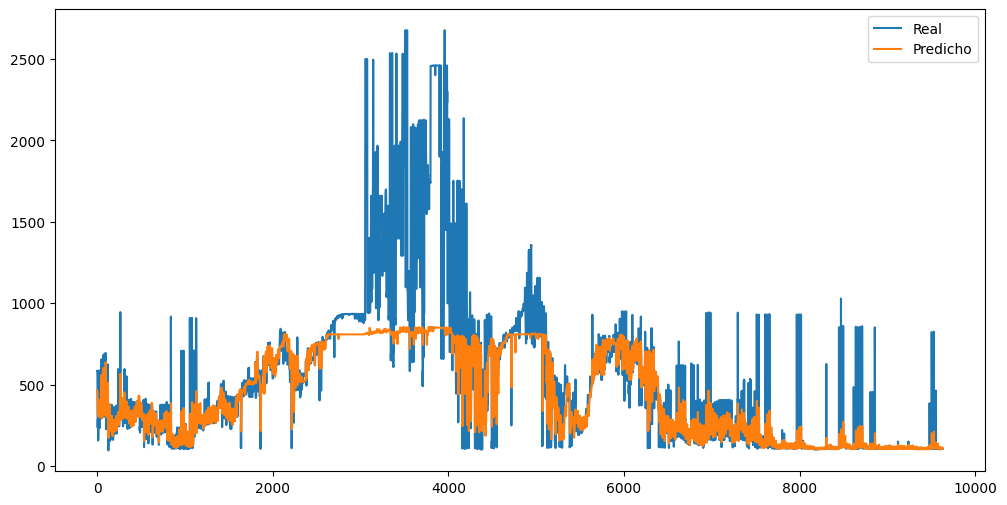

In [50]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()